<a href="https://colab.research.google.com/github/senthil-kumar-7/food-delivery-analytics-project/blob/main/food_delivery_analytics_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total Orders in Anna Nagar: 11
--------------------------------------------------


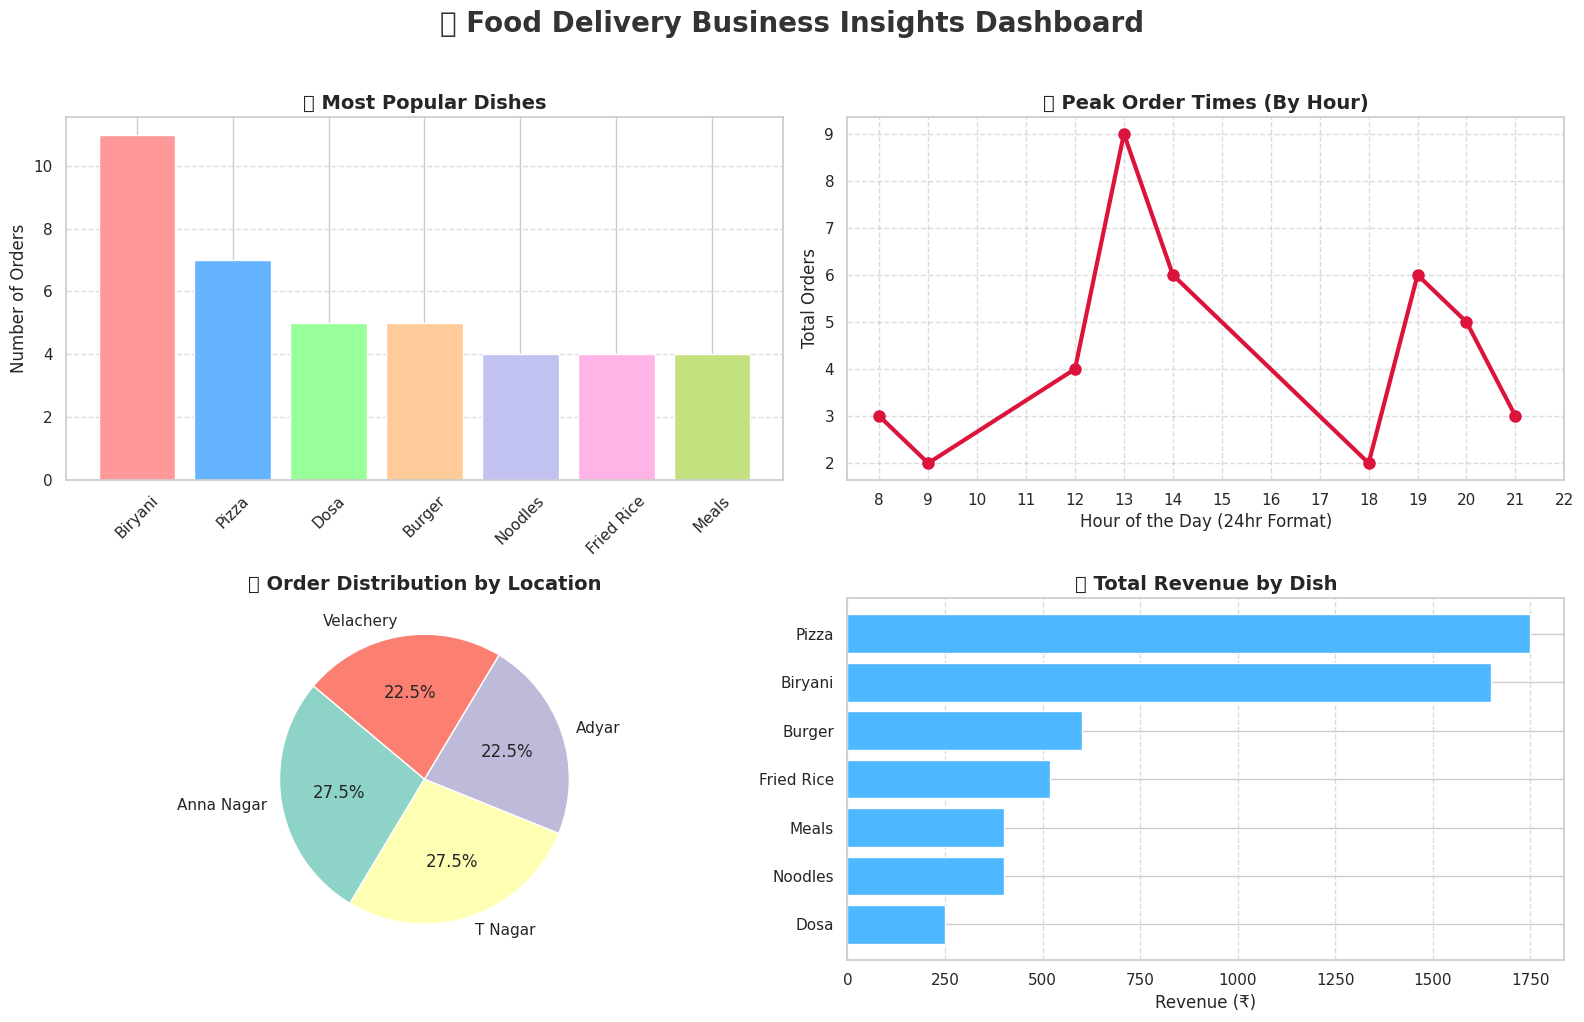

In [11]:
# Thevaiyana libraries import pandrom
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Entha oru unnecessary warnings-um varama thadukka intha line
warnings.filterwarnings('ignore')

# --- 1. DATASET URUVAKUTHAL ---
data = {
    'Order_ID': range(1, 41),
    'Item_Name': ['Biryani', 'Pizza', 'Dosa', 'Burger', 'Noodles', 'Biryani', 'Fried Rice', 'Pizza', 'Dosa', 'Biryani',
                  'Meals', 'Burger', 'Biryani', 'Noodles', 'Pizza', 'Dosa', 'Biryani', 'Fried Rice', 'Burger', 'Meals',
                  'Biryani', 'Pizza', 'Noodles', 'Dosa', 'Biryani', 'Fried Rice', 'Pizza', 'Burger', 'Biryani', 'Meals',
                  'Pizza', 'Biryani', 'Dosa', 'Noodles', 'Burger', 'Biryani', 'Pizza', 'Fried Rice', 'Meals', 'Biryani'],
    'Order_Time': ['12:30', '19:00', '08:30', '19:30', '20:30', '13:00', '13:15', '20:00', '09:00', '12:45',
                   '13:30', '18:30', '14:00', '21:00', '19:45', '08:45', '13:10', '14:20', '20:15', '13:50',
                   '12:50', '21:30', '19:15', '09:30', '13:40', '14:10', '20:45', '19:10', '13:20', '14:00',
                   '20:10', '13:45', '08:15', '21:15', '18:45', '12:15', '19:30', '14:30', '13:15', '14:45'],
    'Price': [150, 250, 50, 120, 100, 150, 130, 250, 50, 150, 100, 120, 150, 100, 250, 50, 150, 130, 120, 100,
              150, 250, 100, 50, 150, 130, 250, 120, 150, 100, 250, 150, 50, 100, 120, 150, 250, 130, 100, 150],
    'Location': ['Anna Nagar', 'T Nagar', 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar', 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar',
                 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar', 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar', 'Adyar', 'Velachery',
                 'Anna Nagar', 'T Nagar', 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar', 'Adyar', 'Velachery', 'Anna Nagar', 'T Nagar',
                 'Velachery', 'Anna Nagar', 'Adyar', 'T Nagar', 'Anna Nagar', 'T Nagar', 'Velachery', 'Adyar', 'Anna Nagar', 'T Nagar']
}
df = pd.DataFrame(data)

# --- 2. DATA CLEANING & PREPARATION ---
# .copy() use pandrathala 'SettingWithCopyWarning' varathu
df_cleaned = df.dropna().copy()

# Time column-la irunthu Hour-a mattum thaniya pirichi edukurom
df_cleaned['Hour'] = pd.to_datetime(df_cleaned['Order_Time'], format='%H:%M').dt.hour

# --- 3. FILTERING TASK (Syllabus Requirement) ---
# Oru specific area-va (eg: Anna Nagar) mattum filter panni analyze panna
# Itha project report-la 'Filtering usage' nu kaatikkalam
filtered_df = df_cleaned[df_cleaned['Location'] == 'Anna Nagar']
print(f"Total Orders in Anna Nagar: {len(filtered_df)}")
print("-" * 50)

# --- 4. BUSINESS DASHBOARD URUVAKUTHAL (Matplotlib) ---
# Orey image-la 4 charts vara maari 2x2 grid set pandrom
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('🍔 Food Delivery Business Insights Dashboard', fontsize=20, fontweight='bold', color='#333333', y=1.02)

# --- Chart 1: Most Popular Dishes (Bar Chart) ---
popular_dishes = df_cleaned['Item_Name'].value_counts()
axes[0, 0].bar(popular_dishes.index, popular_dishes.values, color=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0', '#ffb3e6', '#c4e17f'])
axes[0, 0].set_title('🍕 Most Popular Dishes', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Peak Order Times (Line Chart) ---
peak_times = df_cleaned['Hour'].value_counts().sort_index()
axes[0, 1].plot(peak_times.index, peak_times.values, marker='o', color='crimson', linewidth=3, markersize=8)
axes[0, 1].set_title('📈 Peak Order Times (By Hour)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Hour of the Day (24hr Format)', fontsize=12)
axes[0, 1].set_ylabel('Total Orders', fontsize=12)
axes[0, 1].set_xticks(range(8, 23)) # Setting hours from 8 AM to 10 PM
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# --- Chart 3: Order Distribution by Location (Pie Chart) ---
location_counts = df_cleaned['Location'].value_counts()
axes[1, 0].pie(location_counts.values, labels=location_counts.index, autopct='%1.1f%%', startangle=140, colors=['#8dd3c7','#ffffb3','#bebada','#fb8072'])
axes[1, 0].set_title('📍 Order Distribution by Location', fontsize=14, fontweight='bold')

# --- Chart 4: Total Revenue by Dish (Bar Chart) ---
revenue_by_dish = df_cleaned.groupby('Item_Name')['Price'].sum().sort_values(ascending=False)
axes[1, 1].barh(revenue_by_dish.index, revenue_by_dish.values, color='#4db8ff')
axes[1, 1].set_title('💰 Total Revenue by Dish', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Revenue (₹)', fontsize=12)
axes[1, 1].invert_yaxis() # Top revenue item mela vara vaikurathu
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.7)

# Dashboard-a alaga arrange panni display pandrom
plt.tight_layout()
plt.show()